# EconAgent — Análisis de resultados


Estos son los análisis de una corrida. Los archivso en datos son todos generados por la corrida, salvo profiles.json que fueron generados al inicio. Se sospecha con alguna base de datos de estatistica gubernamentales


In [2]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (12, 4)

# Examinamos los archivos

 Descripción de Archivos

| Archivo / Carpeta | Descripción |
| :--- | :--- |
| `env_6.pkl`, `env_12.pkl` | El objeto `env` completo (estado de Foundation) serializado en el paso 6 y 12. |
| `obs_6.pkl`, `obs_12.pkl` | La observación devuelta por el `env` en ese paso. |
| `actions_6.pkl`, `actions_12.pkl` | Las acciones `[work, consumption]` decodificadas del JSON de GPT para cada agente. |
| `dialog_6.pkl`, `dialog_12.pkl` | La cola corta de diálogo (`dialog_queue`, `maxlen=3`) que se manda como contexto a GPT en cada llamada. |
| `dialog4ref_6.pkl`, `dialog4ref_12.pkl` | La cola larga de diálogo (`maxlen=7`) que alimenta las reflexiones trimestrales. |
| `dense_log.pkl`, `dense_log_6.pkl`, `dense_log_12.pkl` | El log denso de Foundation: histórico completo de estados/acciones/recompensas de la simulación, paso a paso (esto es lo que después analiza `analysis.ipynb`). |
| `dialogs/` | Carpeta con un archivo de texto por agente (nombre del agente = nombre del archivo), con el historial completo de la conversación en texto plano (lo que escribe `simulate.py:127-130`) — útil para leer "a mano" qué le contestó el LLM a cada agente mes a mes. |

## 1. Cargar resultados


In [8]:
from pprint import pprint

actions_6_path = run_path / 'actions_6.pkl'

if actions_6_path.exists():
    with open(actions_6_path, 'rb') as f:
        actions_6 = pkl.load(f)
    print(f'Archivo cargado: {actions_6_path.name}')
else:
    actions_6 = log.get('actions_6', None)
    print('No se encontró actions_6.pkl; usando log["actions_6"] si existe.')

print('Tipo:', type(actions_6))

if isinstance(actions_6, pd.DataFrame):
    display(actions_6)
elif isinstance(actions_6, (list, tuple)):
    pprint(actions_6[:5])
    print(f'Longitud: {len(actions_6)}')
elif isinstance(actions_6, dict):
    pprint(actions_6)
else:
    print(actions_6)

Archivo cargado: actions_6.pkl
Tipo: <class 'dict'>
{'0': [1, 25.0],
 '1': [1, 25.0],
 '10': [1, 25.0],
 '11': [1, 25.0],
 '12': [1, 25.0],
 '13': [1, 25.0],
 '14': [1, 25.0],
 '15': [1, 25.0],
 '16': [1, 25.0],
 '17': [1, 25.0],
 '18': [1, 25.0],
 '19': [1, 25.0],
 '2': [1, 25.0],
 '20': [1, 25.0],
 '21': [1, 25.0],
 '22': [1, 25.0],
 '23': [1, 25.0],
 '24': [1, 25.0],
 '25': [1, 25.0],
 '26': [1, 25.0],
 '27': [1, 25.0],
 '28': [1, 25.0],
 '29': [1, 25.0],
 '3': [1, 25.0],
 '30': [1, 25.0],
 '31': [1, 25.0],
 '32': [1, 25.0],
 '33': [1, 25.0],
 '34': [1, 25.0],
 '35': [1, 25.0],
 '36': [1, 25.0],
 '37': [1, 25.0],
 '38': [1, 25.0],
 '39': [1, 25.0],
 '4': [1, 25.0],
 '40': [1, 25.0],
 '41': [1, 25.0],
 '42': [1, 25.0],
 '43': [1, 25.0],
 '44': [1, 25.0],
 '45': [1, 25.0],
 '46': [1, 25.0],
 '47': [1, 25.0],
 '48': [1, 25.0],
 '49': [1, 25.0],
 '5': [1, 25.0],
 '50': [1, 25.0],
 '51': [1, 25.0],
 '52': [1, 25.0],
 '53': [1, 25.0],
 '54': [1, 25.0],
 '55': [1, 25.0],
 '56': [1, 25.0],


archivo actions_6.pkl muestra los 10 agentes y el gobierno (p de planner) donde todos los agentes deciden trabajar e incrementar su consumo 25 unidaes
### 1. El LLM devuelve un porcentaje (0 a 1)
El prompt le pide al LLM: "'consumption' (a value between 0 and 1 with intervals of 0.02)" — es decir, algo como 0.5 = "quiero gastar el 50% de mis ahorros+ingreso disponible en bienes esenciales".

### 2. simulate.py convierte ese porcentaje en un índice discreto

extracted_actions[1] /= 0.02
(simulate.py:122)

Si el LLM contestó consumption = 0.5, esto hace 0.5 / 0.02 = 25. Ese 25 es el número que terminás viendo guardado en actions_6.pkl. No es "25 dólares" ni "25%" — es un índice de acción discreta dentro de una grilla de 50 posiciones (n_actions = 1.0/0.02 = 50, simple_consumption.py:35).

### 3. Foundation vuelve a convertir ese índice en tasa real
Cuando Foundation ejecuta el step, el componente SimpleConsumption toma esa acción (action=25) y hace la operación inversa:


consumption_rate = action * self.consumption_rate_step   # 25 * 0.02 = 0.5
(simple_consumption.py:84)

Es decir: 25 × 0.02 = 0.5 → 50% de la tasa de consumo, que es exactamente el mismo porcentaje que el LLM dijo originalmente en el prompt.

Por qué existe este ida y vuelta
Foundation (heredado del paper RL original) espera acciones discretas porque las redes de política PPO tienen una cabeza de clasificación (softmax sobre 50 categorías), no un valor continuo. El LLM en cambio razona más naturalmente en porcentajes continuos (0 a 1). Entonces:

LLM → índice: se divide por 0.02 para "encajar" la respuesta continua del LLM en la grilla discreta de 50 acciones que espera el motor de Foundation.
índice → efecto real: Foundation multiplica por 0.02 de vuelta para recuperar la tasa real y calcular cuánto dinero gasta el agente ese mes.
En resumen: 25.0 guardado en el .pkl es un artefacto de codificación intermedio (el índice de acción), y su significado económico real es simplemente 25 × 0.02 = 0.5 = el agente gastó el 50% de lo disponible ese mes.

In [5]:
# Listá las simulaciones disponibles
data_dir = Path('data')
runs = sorted([p for p in data_dir.iterdir() if p.is_dir()])
for i, r in enumerate(runs):
    print(f'[{i}] {r.name}')

[0] gpt-3-noperception-reflection-1-100agents-240months
[1] gpt-3-noperception-reflection-1-100agents-24months
[2] gpt-3-noperception-reflection-1-10agents-12months


In [9]:
# Elegí el índice de la simulación a analizar
RUN_IDX = 0
run_path = runs[RUN_IDX]
print(f'Analizando: {run_path.name}')

with open(run_path / 'dense_log.pkl', 'rb') as f:
    log = pkl.load(f)

print('\nClaves disponibles en dense_log:')
print(list(log.keys()))

Analizando: gpt-3-noperception-reflection-1-100agents-240months


FileNotFoundError: [Errno 2] No such file or directory: 'data/gpt-3-noperception-reflection-1-100agents-240months/dense_log.pkl'

## 2. Extraer series de tiempo


In [22]:
T = len(log['states'])
n_agents = len([k for k in log['states'][0].keys() if k != 'p'])
print(f'Pasos: {T}   Agentes: {n_agents}')

# --- Macroeconómicos (world) ---
world_df = pd.DataFrame(log['world'])
world_df.index.name = 'step'

# --- Estados de agentes ---
wealth    = np.array([[log['states'][t][str(i)]['inventory']['Coin']  for i in range(n_agents)] for t in range(T)])
income    = np.array([[log['states'][t][str(i)].get('income', {}).get('Coin', 0) for i in range(n_agents)] for t in range(T)])
skill     = np.array([[log['states'][t][str(i)]['skill']               for i in range(n_agents)] for t in range(T)])

print('world_df columnas:', list(world_df.columns))

Pasos: 25   Agentes: 100
world_df columnas: ['Price', '#Products', 'Interest Rate', 'Unemployment Rate', 'Real GDP', 'Nominal GDP', 'Price Inflation', 'Unemployment Rate Growth', 'Wage Inflation', 'Nominal GDP Growth', 'Real GDP Growth']


## 3. Indicadores macroeconómicos


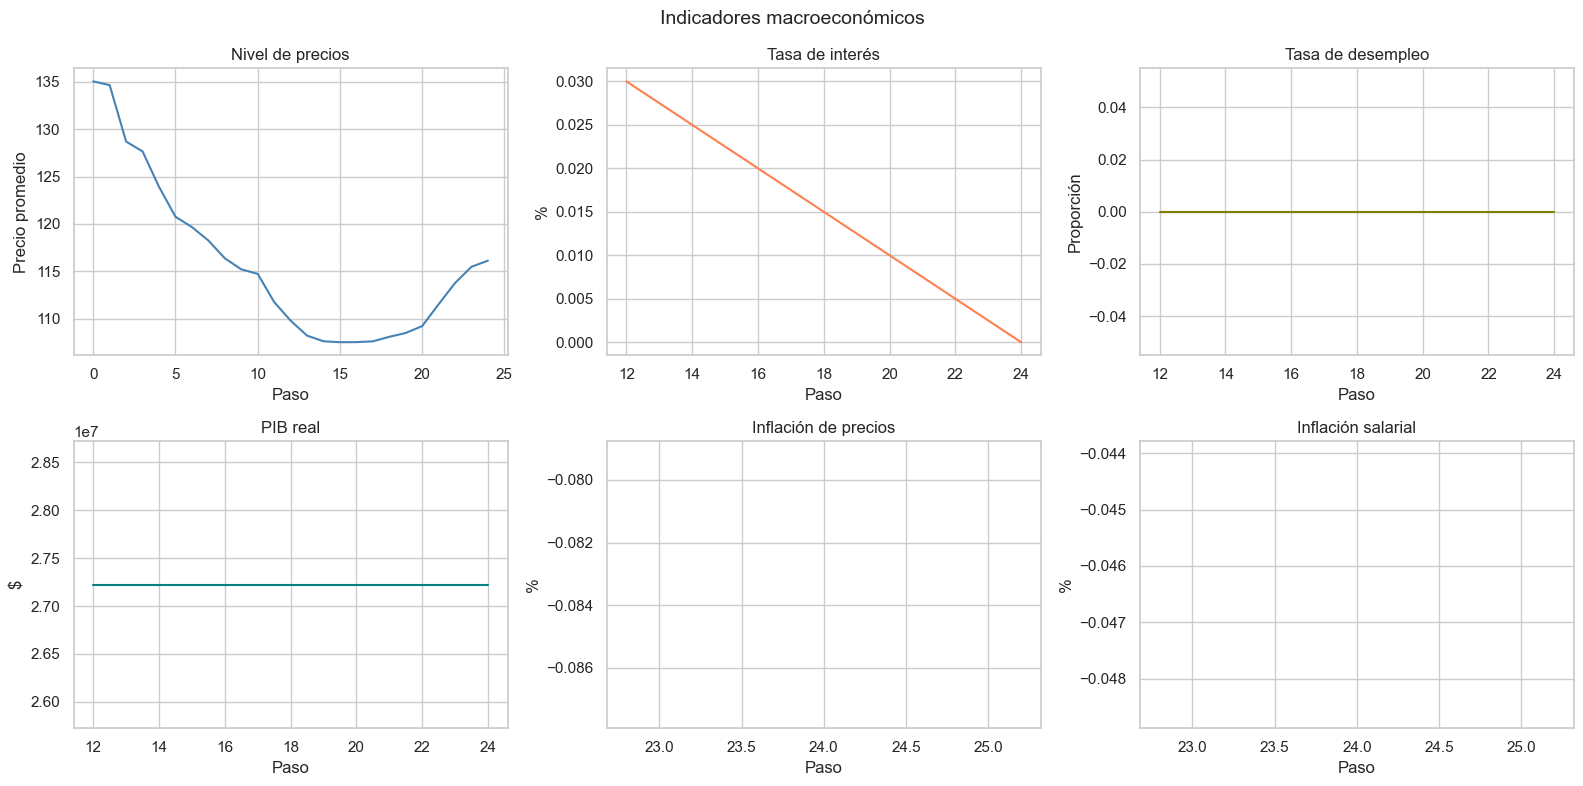

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Indicadores macroeconómicos', fontsize=14)
steps = range(T)

def plot_series(ax, series, title, ylabel, color='steelblue'):
    clean = series.dropna()
    ax.plot(clean.index, clean.values, color=color)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Paso')

plot_series(axes[0,0], world_df['Price'],           'Nivel de precios',      'Precio promedio')
plot_series(axes[0,1], world_df.get('Interest Rate', pd.Series(dtype=float)), 'Tasa de interés', '%', color='coral')
plot_series(axes[0,2], world_df.get('Unemployment Rate', pd.Series(dtype=float)), 'Tasa de desempleo', 'Proporción', color='olive')
plot_series(axes[1,0], world_df.get('Real GDP', pd.Series(dtype=float)),       'PIB real',      '$', color='teal')
plot_series(axes[1,1], world_df.get('Price Inflation', pd.Series(dtype=float)), 'Inflación de precios', '%', color='tomato')
plot_series(axes[1,2], world_df.get('Wage Inflation', pd.Series(dtype=float)),  'Inflación salarial',  '%', color='mediumpurple')

plt.tight_layout()
plt.show()

## 4. Distribución de riqueza


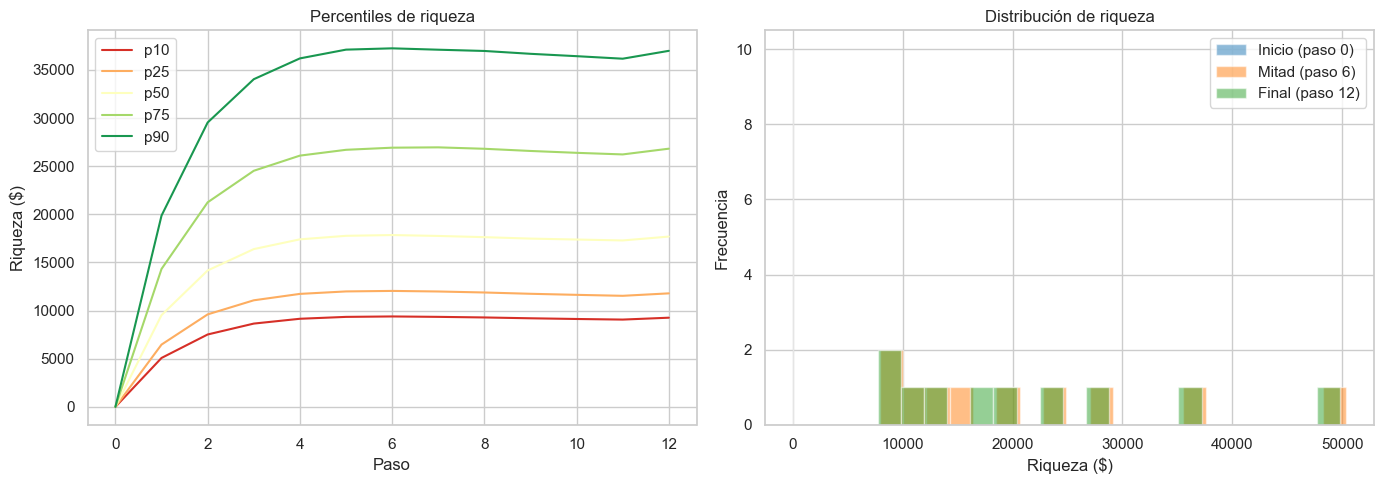

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Percentiles de riqueza a lo largo del tiempo
ax = axes[0]
quantiles = [10, 25, 50, 75, 90]
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(quantiles)))
for q, c in zip(quantiles, colors):
    ax.plot(np.percentile(wealth, q, axis=1), label=f'p{q}', color=c)
ax.set_title('Percentiles de riqueza')
ax.set_xlabel('Paso')
ax.set_ylabel('Riqueza ($)')
ax.legend()

# Distribución al inicio, mitad y final
ax = axes[1]
checkpoints = [0, T//2, T-1]
labels = ['Inicio', 'Mitad', 'Final']
for cp, label in zip(checkpoints, labels):
    ax.hist(wealth[cp], bins=20, alpha=0.5, label=f'{label} (paso {cp})')
ax.set_title('Distribución de riqueza')
ax.set_xlabel('Riqueza ($)')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()

## 5. Coeficiente de Gini


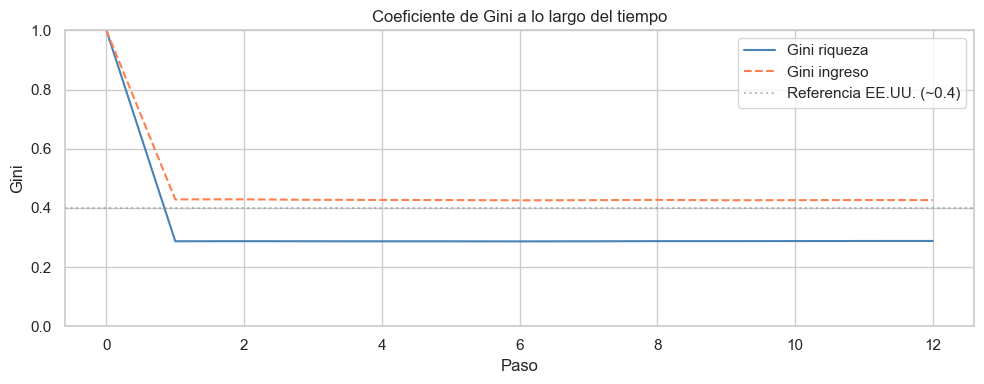

Gini riqueza  — inicio: 1.000  |  final: 0.288
Gini ingreso  — inicio: 1.000  |  final: 0.426


In [11]:
def gini(x):
    x = np.sort(np.abs(x))
    n = len(x)
    return 1 - (2 / (n + 1)) * np.sum(np.cumsum(x) / (np.sum(x) + 1e-10))

gini_wealth = [gini(wealth[t]) for t in range(T)]
gini_income = [gini(income[t]) for t in range(T)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gini_wealth, label='Gini riqueza', color='steelblue')
ax.plot(gini_income, label='Gini ingreso', color='coral', linestyle='--')
ax.set_ylim(0, 1)
ax.set_title('Coeficiente de Gini a lo largo del tiempo')
ax.set_xlabel('Paso')
ax.set_ylabel('Gini')
ax.axhline(0.4, color='gray', linestyle=':', alpha=0.5, label='Referencia EE.UU. (~0.4)')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Gini riqueza  — inicio: {gini_wealth[0]:.3f}  |  final: {gini_wealth[-1]:.3f}')
print(f'Gini ingreso  — inicio: {gini_income[0]:.3f}  |  final: {gini_income[-1]:.3f}')

## 6. Curva de Lorenz (inicio vs final)


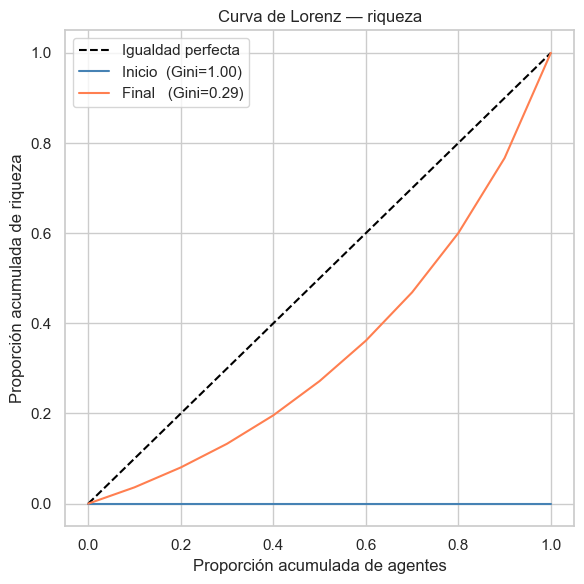

In [12]:
def lorenz(x):
    x = np.sort(np.abs(x))
    cum = np.cumsum(x) / (np.sum(x) + 1e-10)
    return np.concatenate([[0], cum])

fig, ax = plt.subplots(figsize=(6, 6))
pop = np.linspace(0, 1, n_agents + 1)

ax.plot([0, 1], [0, 1], 'k--', label='Igualdad perfecta')
ax.plot(pop, lorenz(wealth[0]),   label=f'Inicio  (Gini={gini_wealth[0]:.2f})',  color='steelblue')
ax.plot(pop, lorenz(wealth[-1]),  label=f'Final   (Gini={gini_wealth[-1]:.2f})', color='coral')

ax.set_title('Curva de Lorenz — riqueza')
ax.set_xlabel('Proporción acumulada de agentes')
ax.set_ylabel('Proporción acumulada de riqueza')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Actividad laboral y consumo


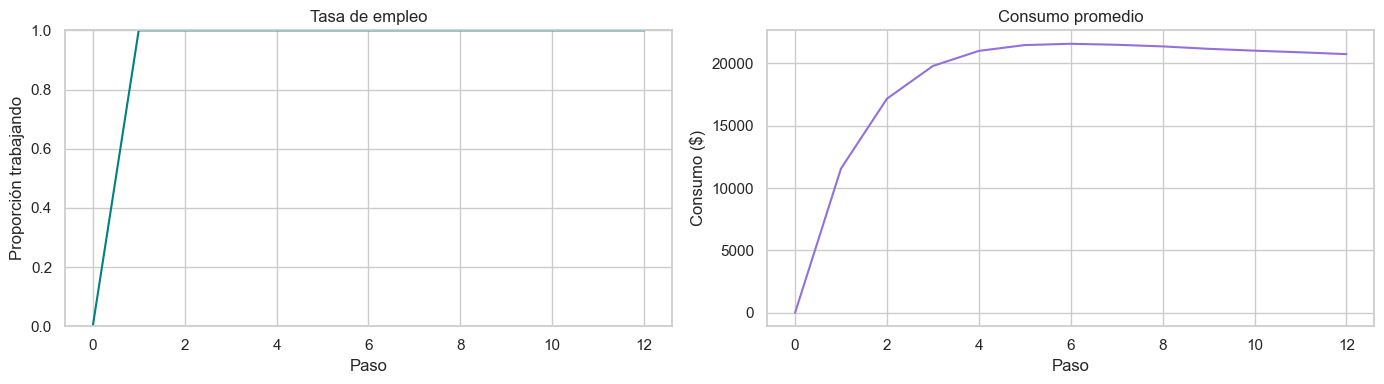

In [13]:
# Tasa de empleo: proporción de agentes que trabajaron en cada paso
if 'SimpleLabor' in log:
    labor_log = log['SimpleLabor']
    labor_rate = [np.mean([a > 0 for a in step.values()]) if isinstance(step, dict) else np.mean(np.array(step) > 0) for step in labor_log]
else:
    labor_rate = [np.mean(income[t] > 0) for t in range(T)]

# Consumo promedio
consumption = np.array([[log['states'][t][str(i)].get('consumption', {}).get('Coin', 0) for i in range(n_agents)] for t in range(T)])
mean_consumption = consumption.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(labor_rate, color='teal')
axes[0].set_ylim(0, 1)
axes[0].set_title('Tasa de empleo')
axes[0].set_xlabel('Paso')
axes[0].set_ylabel('Proporción trabajando')

axes[1].plot(mean_consumption, color='mediumpurple')
axes[1].set_title('Consumo promedio')
axes[1].set_xlabel('Paso')
axes[1].set_ylabel('Consumo ($)')

plt.tight_layout()
plt.show()

## 8. Impuestos y redistribución


In [14]:
tax_key = [k for k in log.keys() if 'BracketTax' in k and 'tax_paid' in k]
lump_key = [k for k in log.keys() if 'BracketTax' in k and 'lump_sum' in k]

if tax_key and lump_key:
    tax_data  = np.array(log[tax_key[0]])   # shape (T, n_agents) or similar
    lump_data = np.array(log[lump_key[0]])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(tax_data.mean(axis=-1) if tax_data.ndim > 1 else tax_data, color='tomato')
    axes[0].set_title('Impuesto promedio pagado')
    axes[0].set_xlabel('Paso')
    axes[0].set_ylabel('$ impuesto')

    axes[1].plot(lump_data.mean(axis=-1) if lump_data.ndim > 1 else lump_data, color='seagreen')
    axes[1].set_title('Lump-sum redistribuido (promedio)')
    axes[1].set_xlabel('Paso')
    axes[1].set_ylabel('$ recibido')

    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron datos de impuestos en el dense_log.')
    print('Claves disponibles:', [k for k in log.keys() if 'Tax' in k or 'tax' in k])

No se encontraron datos de impuestos en el dense_log.
Claves disponibles: ['PeriodicTax']


## 9. Resumen estadístico


In [15]:
summary = pd.DataFrame({
    'Riqueza media':       wealth.mean(axis=1),
    'Riqueza mediana':     np.median(wealth, axis=1),
    'Riqueza std':         wealth.std(axis=1),
    'Ingreso medio':       income.mean(axis=1),
    'Consumo medio':       mean_consumption,
    'Gini riqueza':        gini_wealth,
    'Gini ingreso':        gini_income,
})

print('=== Estadísticas al INICIO ===')
print(summary.iloc[0].to_string())
print('\n=== Estadísticas al FINAL ===')
print(summary.iloc[-1].to_string())

=== Estadísticas al INICIO ===
Riqueza media      0.0
Riqueza mediana    0.0
Riqueza std        0.0
Ingreso medio      0.0
Consumo medio      0.0
Gini riqueza       1.0
Gini ingreso       1.0

=== Estadísticas al FINAL ===
Riqueza media      21364.644207
Riqueza mediana    17685.633852
Riqueza std        12588.723301
Ingreso medio      20595.312432
Consumo medio      20742.373016
Gini riqueza           0.288306
Gini ingreso           0.426386
